In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [18]:
df = pd.read_csv('/PyAi/tvmarketing.csv')
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [19]:
df.shape

(200, 2)

In [4]:
df.isnull().sum()

TV       0
Sales    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

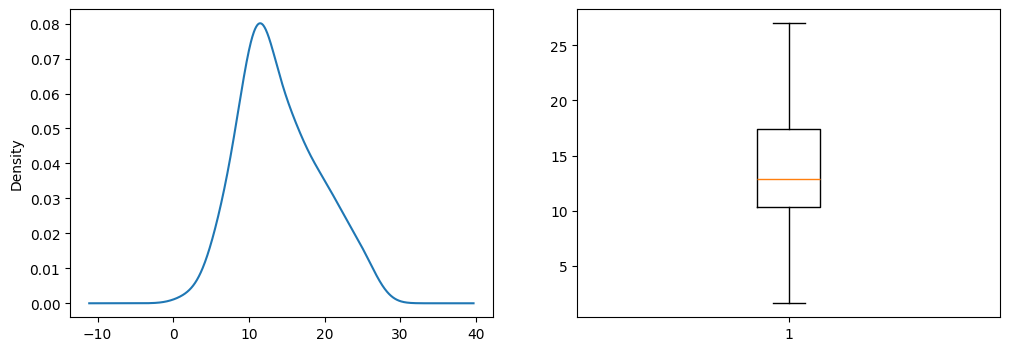

In [6]:
f = plt.figure(figsize=(12,4))
f.add_subplot(1,2,1)
df['Sales'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.boxplot(df['Sales'])
plt.show()

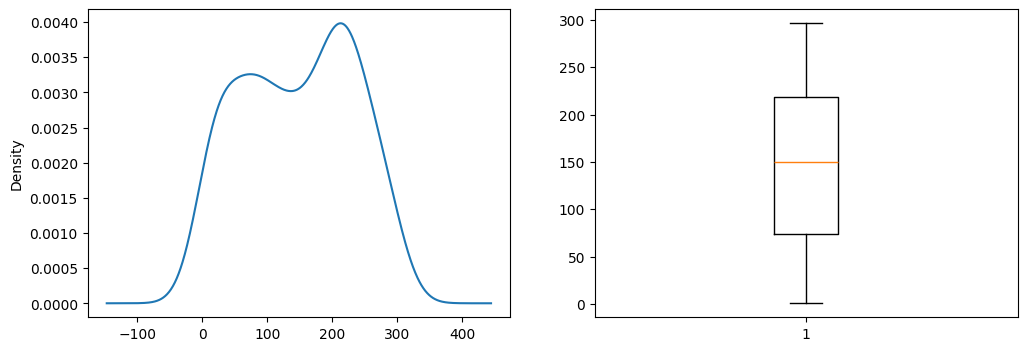

In [7]:
f = plt.figure(figsize=(12,4))
f.add_subplot(1,2,1)
df['TV'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.boxplot(df['TV'])
plt.show()

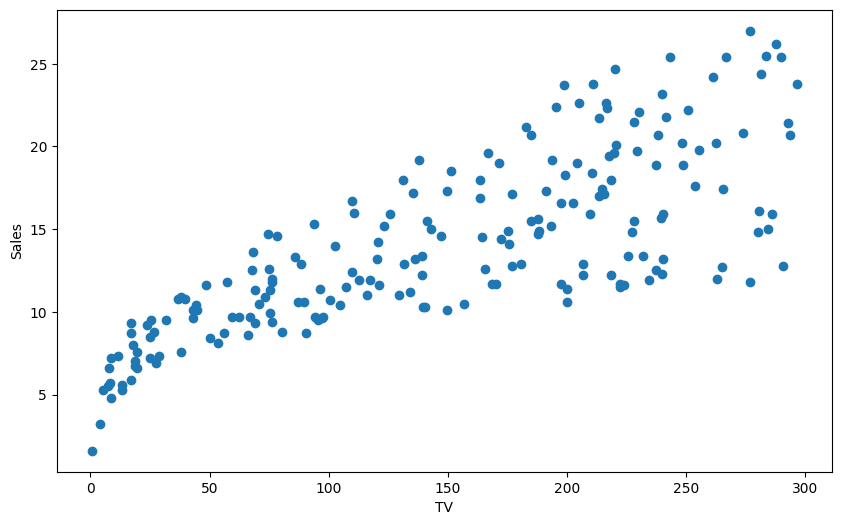

In [8]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df['TV'], df['Sales'])
ax.set_xlabel('TV')
ax.set_ylabel('Sales')
plt.show()

,TV,Sales
TV,1.000000,0.782224
Sales,0.782224,1.000000


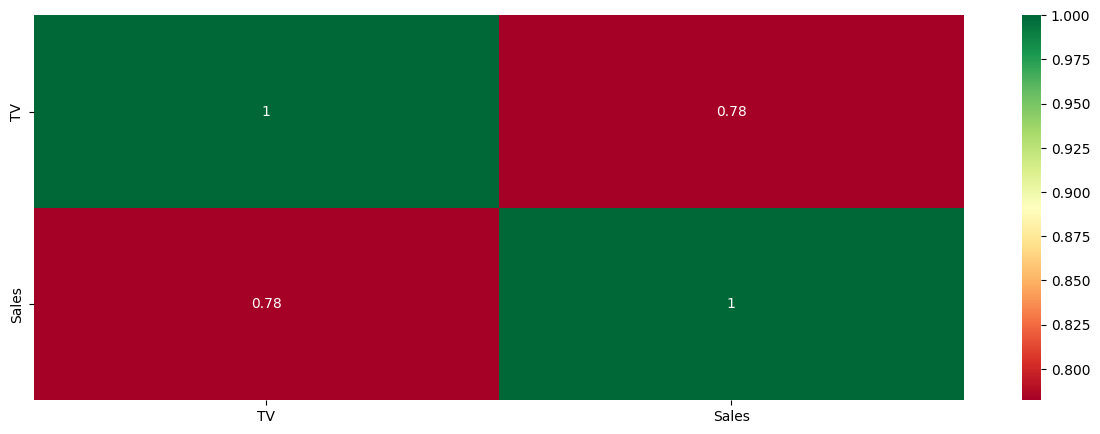

In [9]:
plt.figure(figsize=(15,5))
c = df.corr(numeric_only=True)
sns.heatmap(c, cmap="RdYlGn", annot=True)
c

In [10]:
def train_test_split_np(X, y, test_size=0.2, seed=42):
    np.random.seed(seed)  # legacy random
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    
    n_test = int(len(X) * test_size)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X = df["TV"].to_numpy()
y = df["Sales"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split_np(X, y)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 160
Test: 40


In [11]:
#training model
mean_x = np.mean(X_train)
mean_y = np.mean(y_train)

numerator = np.sum((X_train - mean_x) * (y_train - mean_y))
denominator = np.sum((X_train - mean_x) ** 2)

b1 = numerator / denominator
b0 = mean_y - b1 * mean_x

print("Slope (b1):", b1)
print("Intercept (b0):", b0)

Slope (b1): 0.046529733705443346
Intercept (b0): 7.119638430592953


In [12]:
# rumus prediksi
y_pred = b0 + b1 * X_test

In [13]:
#evaluasi
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true,y_pred))

def r2(y_true,y_pred):
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_res = np.sum((y_true - y_pred)**2)
    return 1 - (ss_res/ss_total)

print("MAE:", mae(y_test,y_pred))
print("MSE:", mse(y_test,y_pred))
print("RMSE:", rmse(y_test,y_pred))
print("R2 Score:", r2(y_test,y_pred))

MAE: 2.444420003751042
MSE: 10.204654118800956
RMSE: 3.194472431998898
R2 Score: 0.6766954295627076


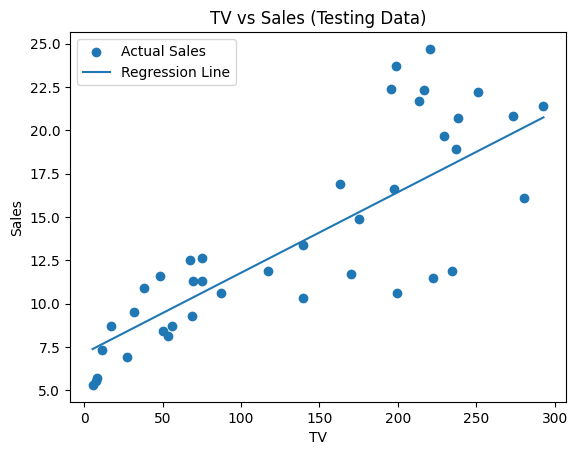

In [14]:
sorted_idx = np.argsort(X_test)

X_sorted = X_test[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.scatter(X_test, y_test, label="Actual Sales")
plt.plot(X_sorted, y_pred_sorted, label="Regression Line")

plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("TV vs Sales (Testing Data)")
plt.legend()

plt.show()

In [15]:
print("\n" + "="*50)
print("PREDIKSI UNTUK TV BUDGET BARU")
print("="*50)

new_tv = [50, 100, 150, 200, 250, 300]
for tv in new_tv:
    pred = b0 + b1 * tv
    print(f"TV Budget: {tv:3d} -> Predicted Sales: {pred:.2f}")


PREDIKSI UNTUK TV BUDGET BARU
TV Budget:  50 -> Predicted Sales: 9.45
TV Budget: 100 -> Predicted Sales: 11.77
TV Budget: 150 -> Predicted Sales: 14.10
TV Budget: 200 -> Predicted Sales: 16.43
TV Budget: 250 -> Predicted Sales: 18.75
TV Budget: 300 -> Predicted Sales: 21.08


In [16]:
import tkinter as tk
import pandas as pd
import numpy as np

# Load & hitung model
df = pd.read_csv('/PyAi/tvmarketing.csv')
b1 = np.cov(df['TV'], df['Sales'])[0,1] / np.var(df['TV'])
b0 = df['Sales'].mean() - b1 * df['TV'].mean()

# GUI
root = tk.Tk()
root.title("TV Predictor")

tk.Label(root, text="TV Budget:").pack()
entry = tk.Entry(root)
entry.pack()
entry.insert(0, "100")

result = tk.Label(root, text="")
result.pack()

def predict():
    result.config(text=f"Sales: {b0 + b1 * float(entry.get()):.2f}")

tk.Button(root, text="Predict", command=predict).pack()

root.mainloop()